In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering

# Métricas internas
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Métricas externas
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, homogeneity_score, completeness_score, v_measure_score

In [ ]:
# Cargar datos
iris = load_iris()
X = iris.data
y_true = iris.target  # Etiquetas reales (para métricas externas)

# Escalar los datos (importante para clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Forma del dataset:", X.shape)
print("Clases reales:", np.unique(y_true))

Forma del dataset: (150, 4)
Clases reales: [0 1 2]


In [ ]:
# --- K-Means ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_scaled)

# --- DBSCAN ---
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_scaled)

# --- Spectral Clustering ---
spectral = SpectralClustering(n_clusters=3, affinity='nearest_neighbors', random_state=42)
labels_spectral = spectral.fit_predict(X_scaled)

In [ ]:
def metricas_internas(X, labels, nombre):
    # Ignorar si solo hay 1 cluster (caso DBSCAN con ruido)
    if len(set(labels)) <= 1:
        print(f"\n{nombre}: No se pueden calcular métricas (solo 1 cluster)")
        return
    mask = labels != -1  # Excluir ruido de DBSCAN
    print(f"\n{'='*40}")
    print(f"Métricas Internas - {nombre}")
    print(f"{'='*40}")
    print(f"  Silhouette Score:         {silhouette_score(X[mask], labels[mask]):.4f}  (mayor es mejor, rango: -1 a 1)")
    print(f"  Davies-Bouldin Score:     {davies_bouldin_score(X[mask], labels[mask]):.4f}  (menor es mejor)")
    print(f"  Calinski-Harabasz Score:  {calinski_harabasz_score(X[mask], labels[mask]):.4f}  (mayor es mejor)")

metricas_internas(X_scaled, labels_kmeans,   "K-Means")
metricas_internas(X_scaled, labels_dbscan,   "DBSCAN")
metricas_internas(X_scaled, labels_spectral, "Spectral Clustering")


Métricas Internas - K-Means
  Silhouette Score:         0.4599  (mayor es mejor, rango: -1 a 1)
  Davies-Bouldin Score:     0.8336  (menor es mejor)
  Calinski-Harabasz Score:  241.9044  (mayor es mejor)

Métricas Internas - DBSCAN
  Silhouette Score:         0.6559  (mayor es mejor, rango: -1 a 1)
  Davies-Bouldin Score:     0.4942  (menor es mejor)
  Calinski-Harabasz Score:  343.9681  (mayor es mejor)

Métricas Internas - Spectral Clustering
  Silhouette Score:         0.4593  (mayor es mejor, rango: -1 a 1)
  Davies-Bouldin Score:     0.8224  (menor es mejor)
  Calinski-Harabasz Score:  229.6799  (mayor es mejor)


In [ ]:
def metricas_externas(y_true, labels, nombre):
    mask = labels != -1
    print(f"\n{'='*40}")
    print(f"Métricas Externas - {nombre}")
    print(f"{'='*40}")
    print(f"  ARI (Adjusted Rand Index):   {adjusted_rand_score(y_true[mask], labels[mask]):.4f}  (1.0 = perfecto)")
    print(f"  NMI (Norm. Mutual Info):     {normalized_mutual_info_score(y_true[mask], labels[mask]):.4f}  (1.0 = perfecto)")
    print(f"  Homogeneity:                 {homogeneity_score(y_true[mask], labels[mask]):.4f}")
    print(f"  Completeness:                {completeness_score(y_true[mask], labels[mask]):.4f}")
    print(f"  V-Measure:                   {v_measure_score(y_true[mask], labels[mask]):.4f}")

metricas_externas(y_true, labels_kmeans,   "K-Means")
metricas_externas(y_true, labels_dbscan,   "DBSCAN")
metricas_externas(y_true, labels_spectral, "Spectral Clustering")


Métricas Externas - K-Means
  ARI (Adjusted Rand Index):   0.6201  (1.0 = perfecto)
  NMI (Norm. Mutual Info):     0.6595  (1.0 = perfecto)
  Homogeneity:                 0.6591
  Completeness:                0.6598
  V-Measure:                   0.6595

Métricas Externas - DBSCAN
  ARI (Adjusted Rand Index):   0.6309  (1.0 = perfecto)
  NMI (Norm. Mutual Info):     0.7602  (1.0 = perfecto)
  Homogeneity:                 0.6132
  Completeness:                1.0000
  V-Measure:                   0.7602

Métricas Externas - Spectral Clustering
  ARI (Adjusted Rand Index):   0.6465  (1.0 = perfecto)
  NMI (Norm. Mutual Info):     0.6838  (1.0 = perfecto)
  Homogeneity:                 0.6737
  Completeness:                0.6941
  V-Measure:                   0.6838


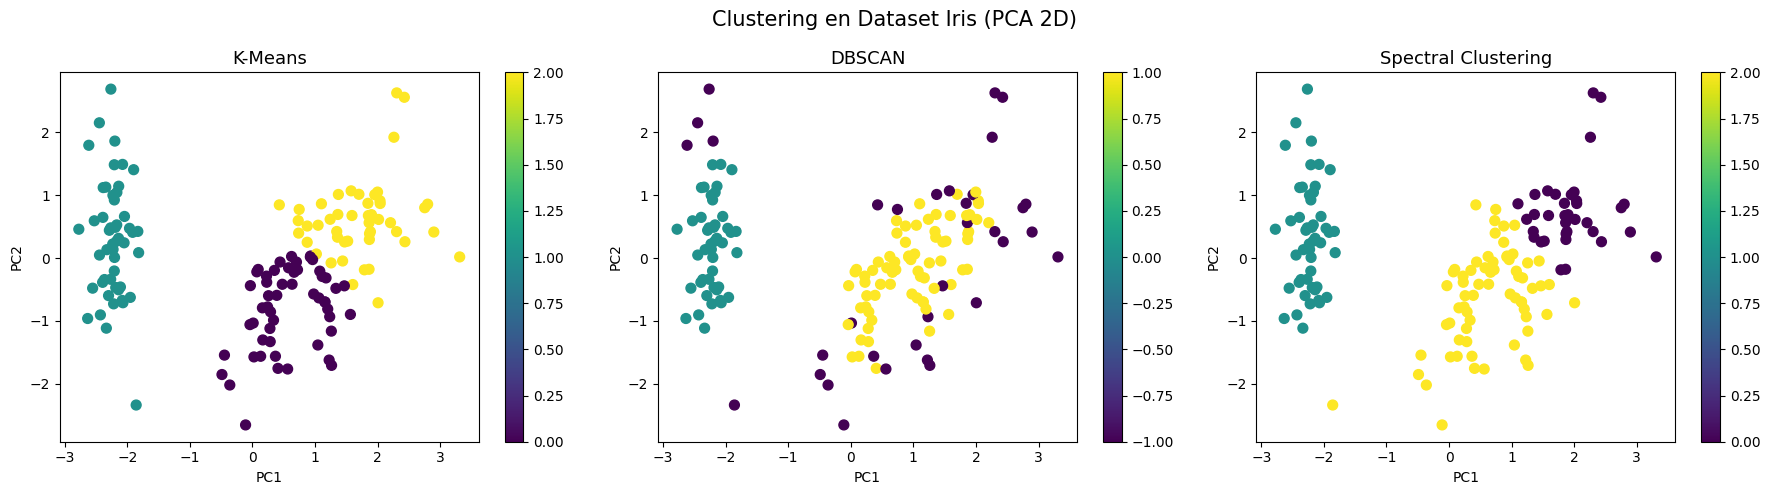

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos = [
    (labels_kmeans,   "K-Means"),
    (labels_dbscan,   "DBSCAN"),
    (labels_spectral, "Spectral Clustering")
]

for ax, (labels, nombre) in zip(axes, modelos):
    scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
    ax.set_title(nombre, fontsize=13)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    plt.colorbar(scatter, ax=ax)

plt.suptitle("Clustering en Dataset Iris (PCA 2D)", fontsize=15)
plt.tight_layout()
plt.show()